# Air Quality Statistical Analysis
**Dataset:** UCI Air Quality — 9,357 hourly observations, March 2004 – April 2005, Italian urban site  
**Hypotheses tested:** H1 (Sensor accuracy by pollutant), H2 (T/RH as confounders), H3 (Temporal patterns), H4 (Inter-pollutant structure via PCA)

In [1]:
import os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
os.makedirs('figures', exist_ok=True)

sys.path.insert(0, 'streamlit_app')
from analysis import (
    load_and_clean, compute_h1_correlations,
    compute_h2_stratified, compute_h2_ols,
    compute_h3_temporal, compute_h4_pca,
    SENSOR_PAIRS, REF_COLS
)
print('Setup complete.')

Setup complete.


## Section 1 — Data Cleaning

In [2]:
XLSX = '/Users/manavananthakumar/Downloads/Projects/AirQuality.xlsx'
raw = pd.read_excel(XLSX)
raw = raw.loc[:, ~raw.columns.str.startswith('Unnamed')]
print(f'Raw shape: {raw.shape}')
print(f'Rows with any -200: {(raw == -200).any(axis=1).sum()}')

df = load_and_clean(save_csv=True)
print(f'\nCleaned shape: {df.shape}')
print(f'Date range: {df.index.min()} → {df.index.max()}')
print(f'Any -200 remaining: {(df == -200).any().any()}')
print('\nMissing % per column:')
display((df.isnull().mean()*100).round(1).rename('Missing %').to_frame())

Raw shape: (9357, 15)
Rows with any -200: 8530



Cleaned shape: (9326, 12)
Date range: 2004-03-10 18:00:00 → 2005-04-04 14:00:00
Any -200 remaining: False

Missing % per column:


,Missing %
CO(GT),17.7
PT08.S1(CO),3.6
C6H6(GT),3.6
PT08.S2(NMHC),3.6
NOx(GT),17.2
PT08.S3(NOx),3.6
NO2(GT),17.3
PT08.S4(NO2),3.6
PT08.S5(O3),3.6
T,3.6


## Section 2 — Exploratory Data Analysis

In [3]:
display(df.describe().round(2))

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,7674.00,8991.00,8991.00,8991.00,7718.00,8991.00,7715.00,8991.00,8991.00,8991.00,8991.00,8991.00
mean,2.15,1099.71,10.08,939.03,246.88,835.37,113.08,1456.14,1022.78,18.32,49.23,1.03
std,1.45,217.08,7.45,266.83,212.97,256.82,48.36,346.20,398.48,8.83,17.32,0.40
min,0.10,647.25,0.15,383.25,2.00,322.00,2.00,551.00,221.00,-1.90,9.18,0.18
25%,1.10,936.75,4.44,734.38,98.00,657.88,78.00,1226.62,731.38,11.79,35.81,0.74
50%,1.80,1063.00,8.24,909.00,179.80,805.50,109.00,1462.75,963.25,17.75,49.55,1.00
75%,2.90,1231.25,13.99,1116.25,326.00,969.25,142.00,1673.50,1273.38,24.40,62.50,1.31
max,11.90,2039.75,63.74,2214.00,1479.00,2682.75,339.70,2775.00,2522.75,44.60,88.73,2.23


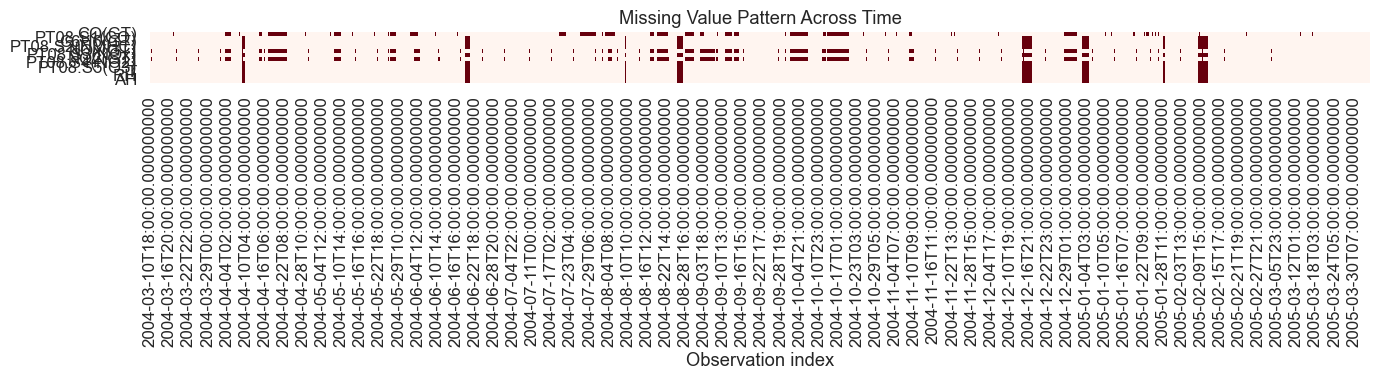

In [4]:
# Missing value heatmap
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(df.isnull().T, cbar=False, cmap='Reds', ax=ax, yticklabels=True)
ax.set_title('Missing Value Pattern Across Time')
ax.set_xlabel('Observation index')
plt.tight_layout()
plt.savefig('figures/eda_missing.png', dpi=150)
plt.show()

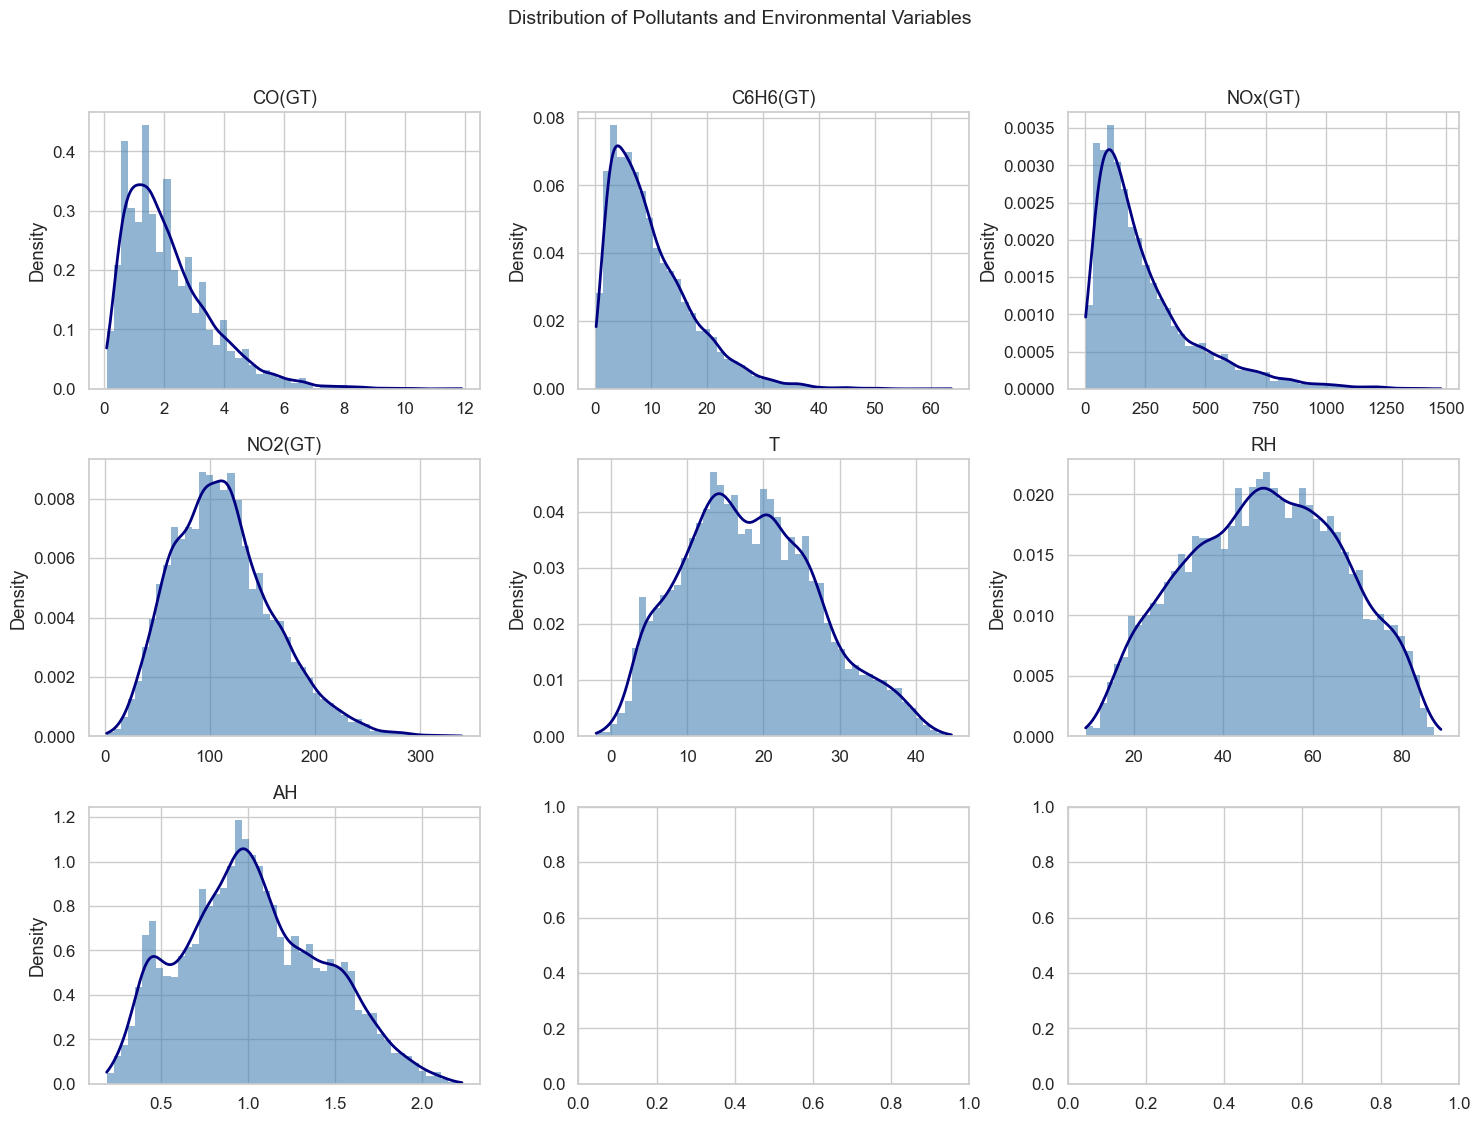

In [5]:
# Distribution plots for reference pollutants
cols_to_plot = REF_COLS + ['T', 'RH', 'AH']
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.flat, cols_to_plot):
    data = df[col].dropna()
    ax.hist(data, bins=50, density=True, alpha=0.6, color='steelblue', edgecolor='none')
    kde = stats.gaussian_kde(data)
    x = np.linspace(data.min(), data.max(), 300)
    ax.plot(x, kde(x), color='navy', lw=2)
    ax.set_title(col)
    ax.set_ylabel('Density')
plt.suptitle('Distribution of Pollutants and Environmental Variables', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('figures/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

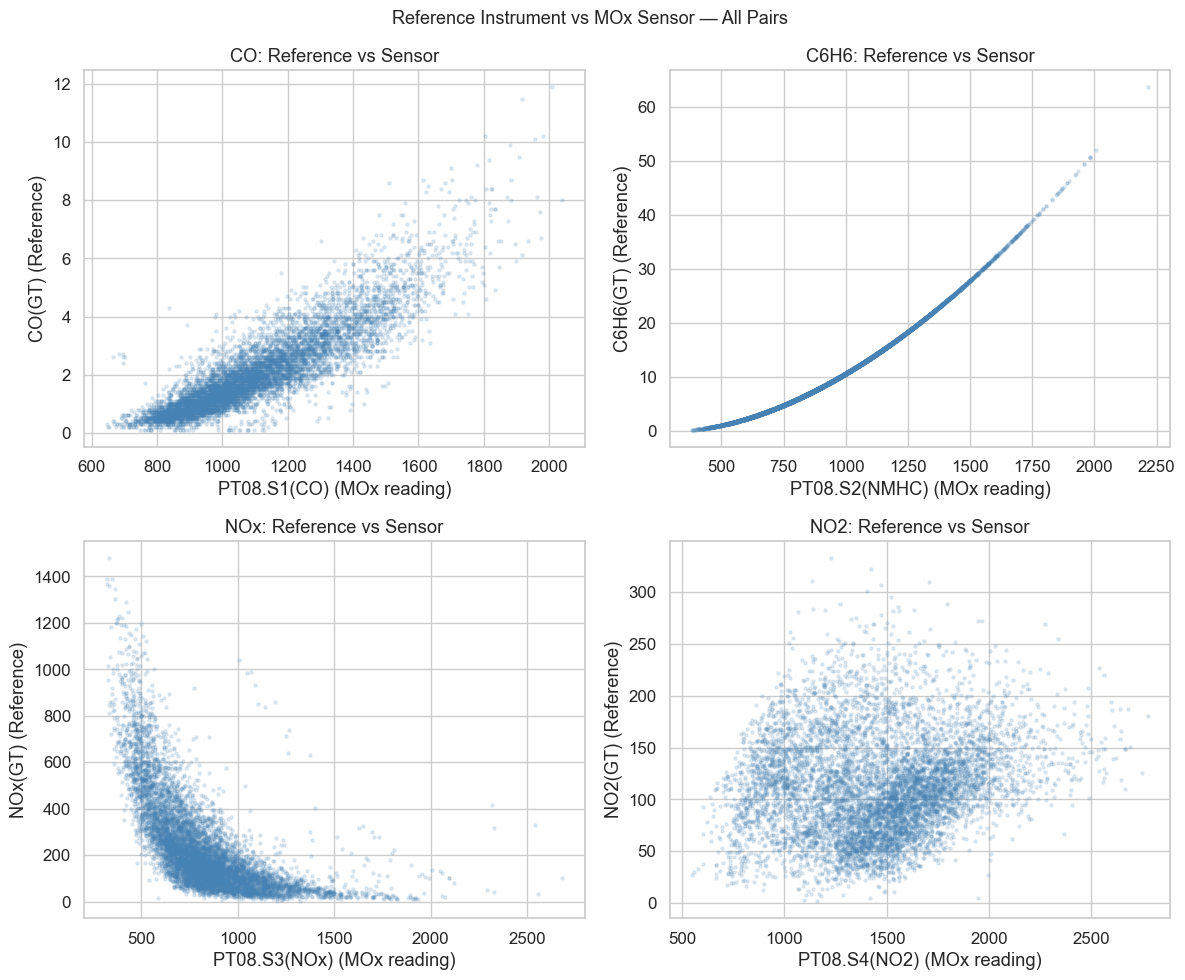

In [6]:
# Reference vs sensor scatter matrix
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, (ref, sensor)) in zip(axes.flat, SENSOR_PAIRS.items()):
    subset = df[[ref, sensor]].dropna()
    ax.scatter(subset[sensor], subset[ref], alpha=0.15, s=5, color='steelblue')
    ax.set_xlabel(f'{sensor} (MOx reading)')
    ax.set_ylabel(f'{ref} (Reference)')
    ax.set_title(f'{name}: Reference vs Sensor')
plt.suptitle('Reference Instrument vs MOx Sensor — All Pairs', fontsize=13)
plt.tight_layout()
plt.savefig('figures/eda_scatter_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 3 — Time Series Overview

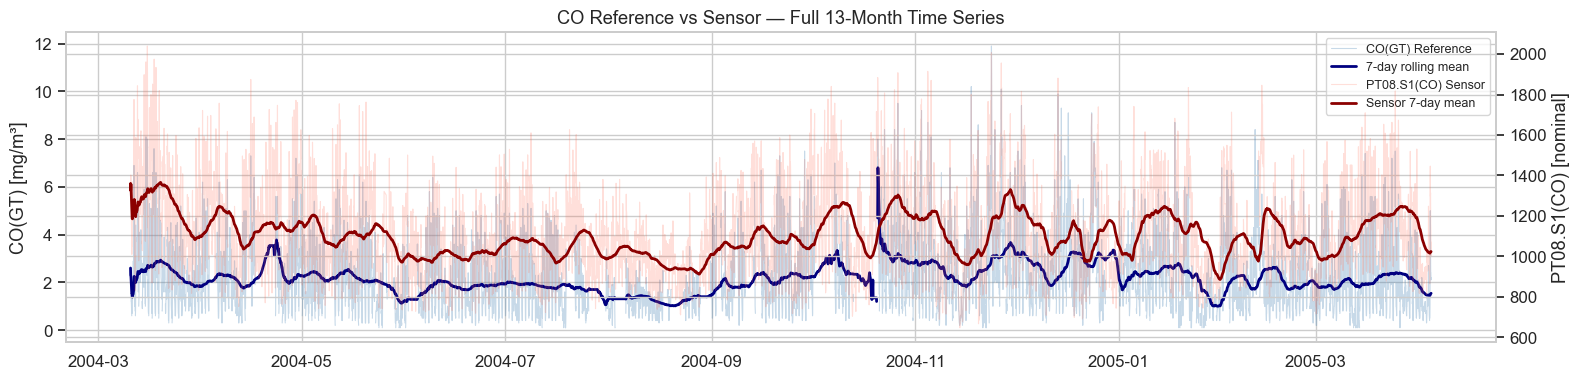

In [7]:
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df.index, df['CO(GT)'], alpha=0.3, lw=0.8, color='steelblue', label='CO(GT) Reference')
ax.plot(df['CO(GT)'].rolling('7D').mean(), color='navy', lw=2, label='7-day rolling mean')
ax2 = ax.twinx()
ax2.plot(df.index, df['PT08.S1(CO)'], alpha=0.2, lw=0.8, color='tomato', label='PT08.S1(CO) Sensor')
ax2.plot(df['PT08.S1(CO)'].rolling('7D').mean(), color='darkred', lw=2, label='Sensor 7-day mean')
ax.set_ylabel('CO(GT) [mg/m³]')
ax2.set_ylabel('PT08.S1(CO) [nominal]')
ax.set_title('CO Reference vs Sensor — Full 13-Month Time Series')
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labs1+labs2, loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('figures/ts_co_full.png', dpi=150, bbox_inches='tight')
plt.show()

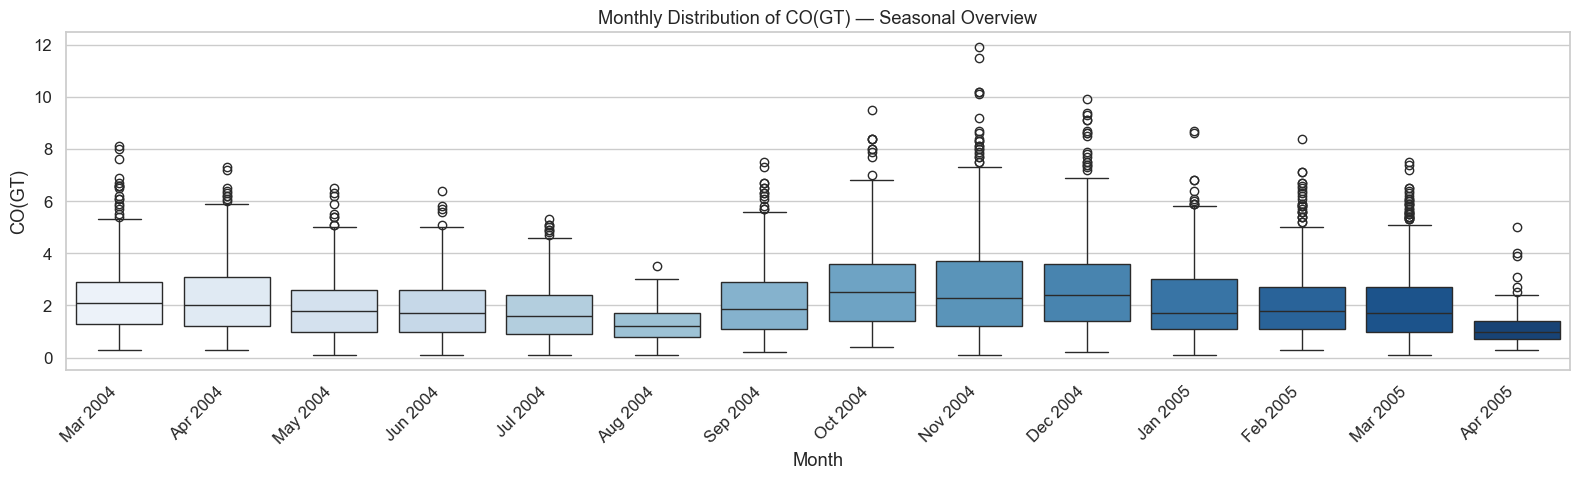

In [8]:
df_tmp = df.copy()
df_tmp['Month'] = df_tmp.index.strftime('%b %Y')
month_order = sorted(df_tmp['Month'].unique(), key=lambda x: pd.to_datetime(x))
fig, ax = plt.subplots(figsize=(16, 5))
sns.boxplot(data=df_tmp, x='Month', y='CO(GT)', order=month_order, ax=ax, palette='Blues')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('Monthly Distribution of CO(GT) — Seasonal Overview')
plt.tight_layout()
plt.savefig('figures/ts_monthly_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 4 — H1: Sensor Accuracy by Pollutant
**Hypothesis:** C6H6 & CO sensors r > 0.80; NOx & NO2 sensors r < 0.70

In [9]:
h1 = compute_h1_correlations(df)

print('=== H1: Pearson r — Reference vs Sensor ===')
for name, res in h1.items():
    tier = 'High (>0.80)' if abs(res['r']) > 0.80 else ('Medium' if abs(res['r']) > 0.70 else 'Low (<0.70)')
    print(f"{name:5s}: r = {res['r']:+.3f}  p = {res['p']:.2e}  Tier: {tier}")

print()
for name, res in h1.items():
    print(f'--- OLS: {name} ---')
    print(res['ols'].summary2().tables[1][['Coef.','Std.Err.','t','P>|t|','[0.025','0.975]']])

=== H1: Pearson r — Reference vs Sensor ===
CO   : r = +0.879  p = 0.00e+00  Tier: High (>0.80)
C6H6 : r = +0.982  p = 0.00e+00  Tier: High (>0.80)
NOx  : r = -0.656  p = 0.00e+00  Tier: Low (<0.70)
NO2  : r = +0.158  p = 2.30e-42  Tier: Low (<0.70)

--- OLS: CO ---
                Coef.  Std.Err.           t  P>|t|    [0.025    0.975]
const       -4.284033  0.041324 -103.670303    0.0 -4.365040 -4.203027
PT08.S1(CO)  0.005776  0.000037  158.188320    0.0  0.005704  0.005847
--- OLS: C6H6 ---
                   Coef.  Std.Err.           t  P>|t|     [0.025     0.975]
const         -15.661008  0.054353 -288.133008    0.0 -15.767553 -15.554462
PT08.S2(NMHC)   0.027416  0.000056  492.389611    0.0   0.027306   0.027525
--- OLS: NOx ---
                   Coef.  Std.Err.           t  P>|t|      [0.025      0.975]
const         676.282919  6.088978  111.066730    0.0  664.346787  688.219052
PT08.S3(NOx)   -0.526568  0.007051  -74.674858    0.0   -0.540391   -0.512745
--- OLS: NO2 ---
      

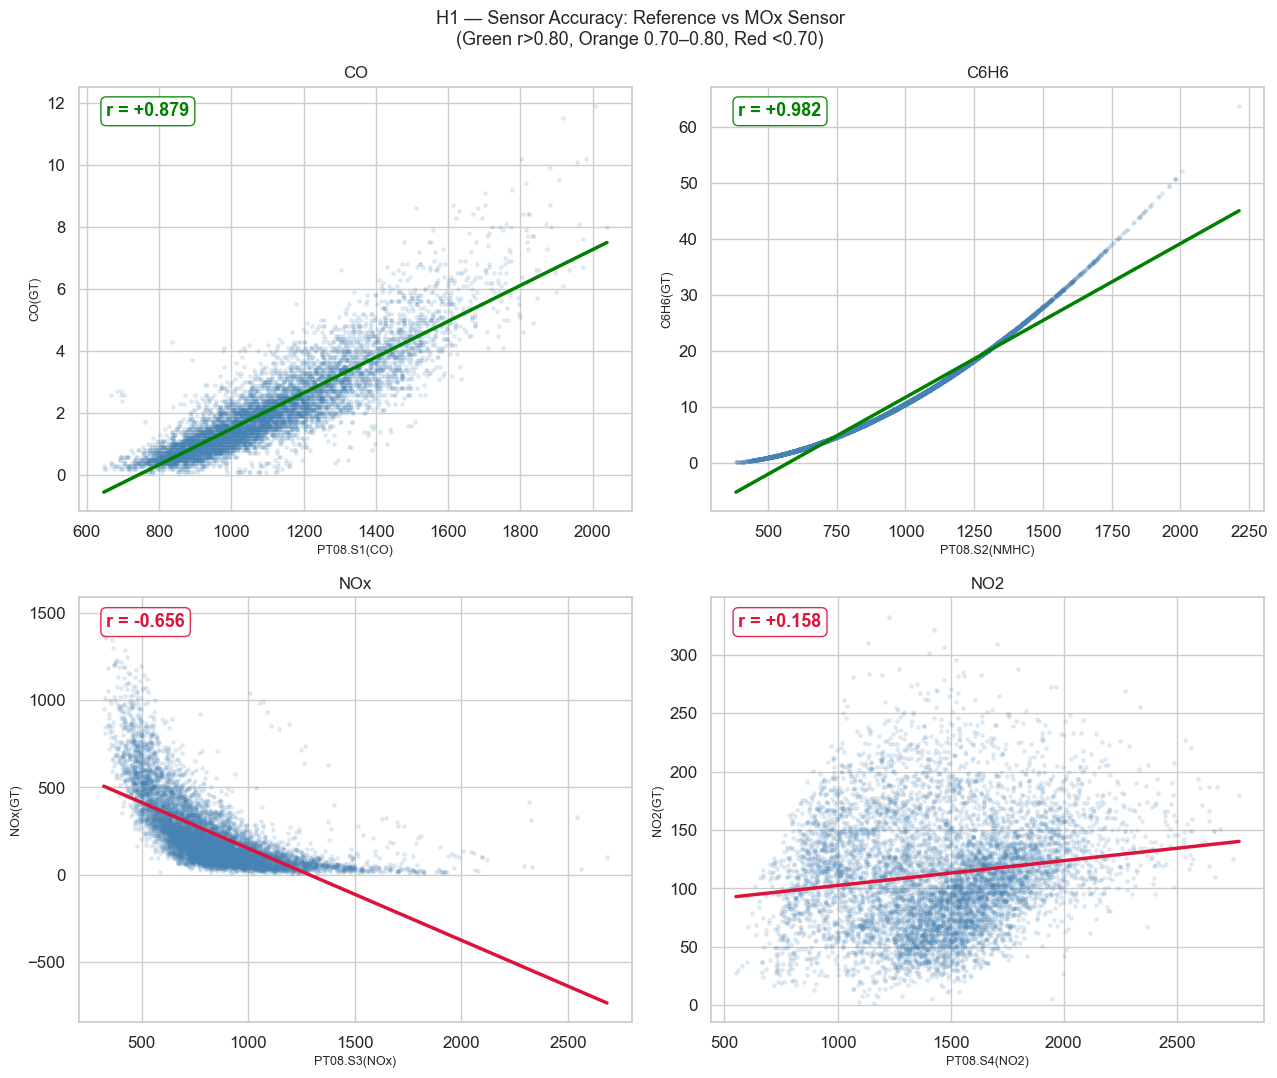

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
colors = {'High (>0.80)': 'green', 'Medium': 'darkorange', 'Low (<0.70)': 'crimson'}

for ax, (name, res) in zip(axes.flat, h1.items()):
    subset = res['data']
    ref, sensor = res['ref'], res['sensor']
    r = res['r']
    tier = 'High (>0.80)' if abs(r) > 0.80 else ('Medium' if abs(r) > 0.70 else 'Low (<0.70)')
    c = colors[tier]

    ax.scatter(subset[sensor], subset[ref], alpha=0.12, s=6, color='steelblue')

    ols = res['ols']
    x_line = np.linspace(subset[sensor].min(), subset[sensor].max(), 200)
    y_line = ols.params.iloc[0] + ols.params.iloc[1] * x_line
    ax.plot(x_line, y_line, color=c, lw=2.5)

    ax.set_xlabel(sensor, fontsize=9)
    ax.set_ylabel(ref, fontsize=9)
    ax.set_title(f'{name}', fontsize=12)
    ax.text(0.05, 0.93, f'r = {r:+.3f}', transform=ax.transAxes,
            fontsize=13, fontweight='bold', color=c,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=c, alpha=0.9))

plt.suptitle('H1 — Sensor Accuracy: Reference vs MOx Sensor\n(Green r>0.80, Orange 0.70–0.80, Red <0.70)', fontsize=13)
plt.tight_layout()
plt.savefig('figures/h1_sensor_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 5 — H2: Temperature & Humidity as Confounders
**Hypothesis:** RH > 70% and T > 25°C degrade sensor accuracy

In [11]:
h2_ols = compute_h2_ols(df)
print('=== H2: OLS Interaction Coefficients ===')
for name, ols in h2_ols.items():
    tbl = ols.summary2().tables[1][['Coef.','Std.Err.','P>|t|']]
    print(f'\n--- {name} ---')
    display(tbl)

=== H2: OLS Interaction Coefficients ===

--- CO ---


,Coef.,Std.Err.,P>|t|
const,-1.274920,0.214848,3.089575e-09
PT08.S1(CO),0.003649,0.000203,9.152404e-71
T,-0.040626,0.005916,7.102002e-12
RH,-0.048676,0.002857,7.547590e-64
T_x_sensor,0.000027,0.000006,9.721309e-07
RH_x_sensor,0.000035,0.000003,2.651590e-40



--- C6H6 ---


,Coef.,Std.Err.,P>|t|
const,-9.095162,0.267465,1.558590e-238
PT08.S2(NMHC),0.020206,0.000295,0.000000e+00
T,-0.230811,0.007024,1.028845e-223
RH,-0.054921,0.003635,6.006441e-51
T_x_sensor,0.000227,0.000008,1.664998e-186
RH_x_sensor,0.000068,0.000004,3.155272e-68



--- NOx ---


,Coef.,Std.Err.,P>|t|
const,703.309574,28.019700,1.693635e-133
PT08.S3(NOx),-0.321957,0.030801,2.140994e-25
T,-9.406139,0.798677,9.826208e-32
RH,3.351212,0.370900,2.056038e-19
T_x_sensor,0.000594,0.000924,5.201894e-01
RH_x_sensor,-0.004992,0.000422,5.087616e-32



--- NO2 ---


,Coef.,Std.Err.,P>|t|
const,74.377627,8.537459,3.644588e-18
PT08.S4(NO2),0.147230,0.006843,1.196396e-99
T,-5.044671,0.259467,3.721134e-82
RH,-0.120313,0.127213,3.443028e-01
T_x_sensor,-0.000051,0.000184,7.804819e-01
RH_x_sensor,-0.001105,0.000092,4.323205e-33


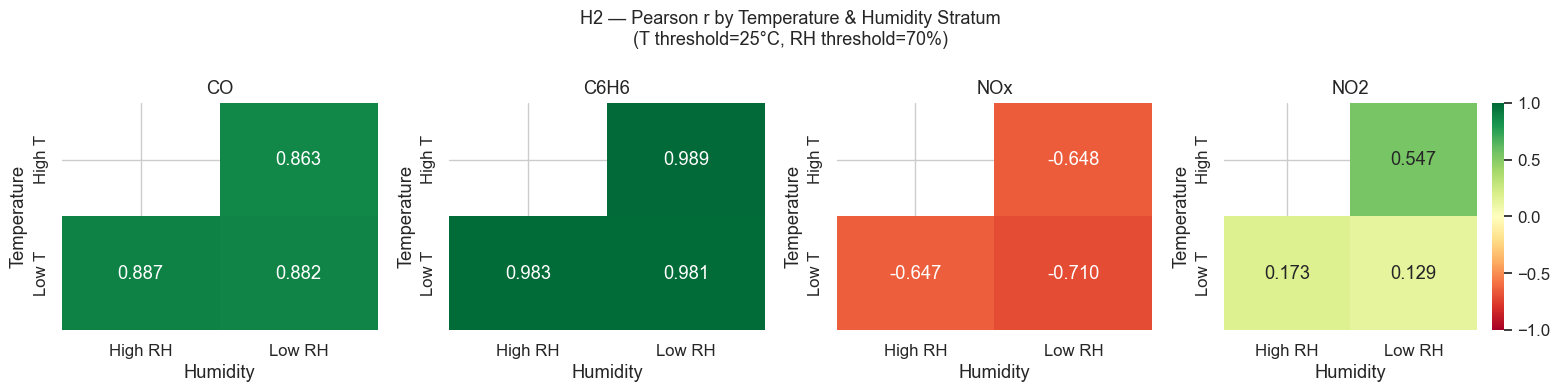

In [12]:
strat = compute_h2_stratified(df, t_thresh=25, rh_thresh=70)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, name in zip(axes, SENSOR_PAIRS.keys()):
    sub = strat[strat['Pollutant'] == name]
    pivot = sub.pivot(index='T_bin', columns='RH_bin', values='r')
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
                vmin=-1, vmax=1, ax=ax, cbar=ax == axes[-1])
    ax.set_title(name)
    ax.set_xlabel('Humidity')
    ax.set_ylabel('Temperature')

plt.suptitle('H2 — Pearson r by Temperature & Humidity Stratum\n(T threshold=25°C, RH threshold=70%)', fontsize=13)
plt.tight_layout()
plt.savefig('figures/h2_confounder_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 6 — H3: Temporal Patterns
**Hypothesis:** Peak levels during rush hours; higher concentrations in winter

In [13]:
h3 = compute_h3_temporal(df)

print('=== H3: One-Way ANOVA ===')
for label, d in [('Hour', h3['anova_hour']), ('Month', h3['anova_month'])]:
    print(f'\nBy {label}:')
    for col, res in d.items():
        sig = '*** SIGNIFICANT' if res['p'] < 0.05 else 'not significant'
        print(f"  {col}: F = {res['F']:.2f}, p = {res['p']:.2e}  → {sig}")

=== H3: One-Way ANOVA ===

By Hour:
  CO(GT): F = 157.93, p = 0.00e+00  → *** SIGNIFICANT
  NOx(GT): F = 67.83, p = 9.71e-287  → *** SIGNIFICANT

By Month:
  CO(GT): F = 48.74, p = 3.68e-104  → *** SIGNIFICANT
  NOx(GT): F = 292.87, p = 0.00e+00  → *** SIGNIFICANT


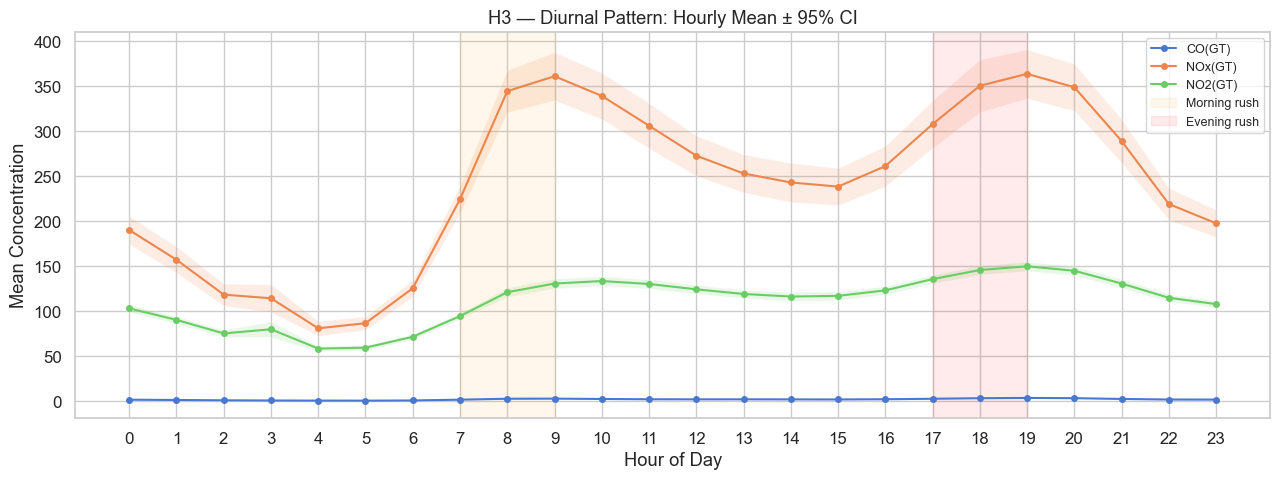

In [14]:
hourly = h3['hourly_mean']
hourly_sem = h3['hourly_sem']
plot_cols = ['CO(GT)', 'NOx(GT)', 'NO2(GT)']

fig, ax = plt.subplots(figsize=(13, 5))
for col in plot_cols:
    ax.plot(hourly.index, hourly[col], marker='o', ms=4, label=col)
    ax.fill_between(hourly.index,
                    hourly[col] - 1.96*hourly_sem[col],
                    hourly[col] + 1.96*hourly_sem[col], alpha=0.15)
ax.axvspan(7, 9, alpha=0.08, color='orange', label='Morning rush')
ax.axvspan(17, 19, alpha=0.08, color='red', label='Evening rush')
ax.set_xticks(range(24))
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Mean Concentration')
ax.set_title('H3 — Diurnal Pattern: Hourly Mean ± 95% CI')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('figures/h3_diurnal.png', dpi=150, bbox_inches='tight')
plt.show()

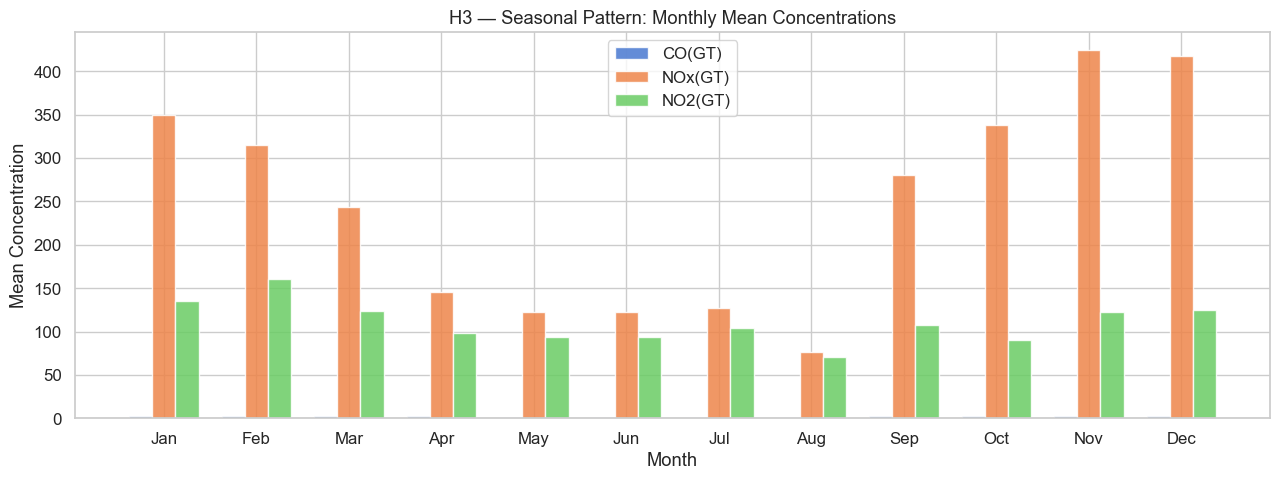

In [15]:
monthly = h3['monthly_mean']
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(monthly.index))
width = 0.25
for i, col in enumerate(plot_cols):
    ax.bar(x + i*width, monthly[col], width, label=col, alpha=0.85)
ax.set_xticks(x + width)
ax.set_xticklabels([month_names[m-1] for m in monthly.index])
ax.set_xlabel('Month')
ax.set_ylabel('Mean Concentration')
ax.set_title('H3 — Seasonal Pattern: Monthly Mean Concentrations')
ax.legend()
plt.tight_layout()
plt.savefig('figures/h3_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()

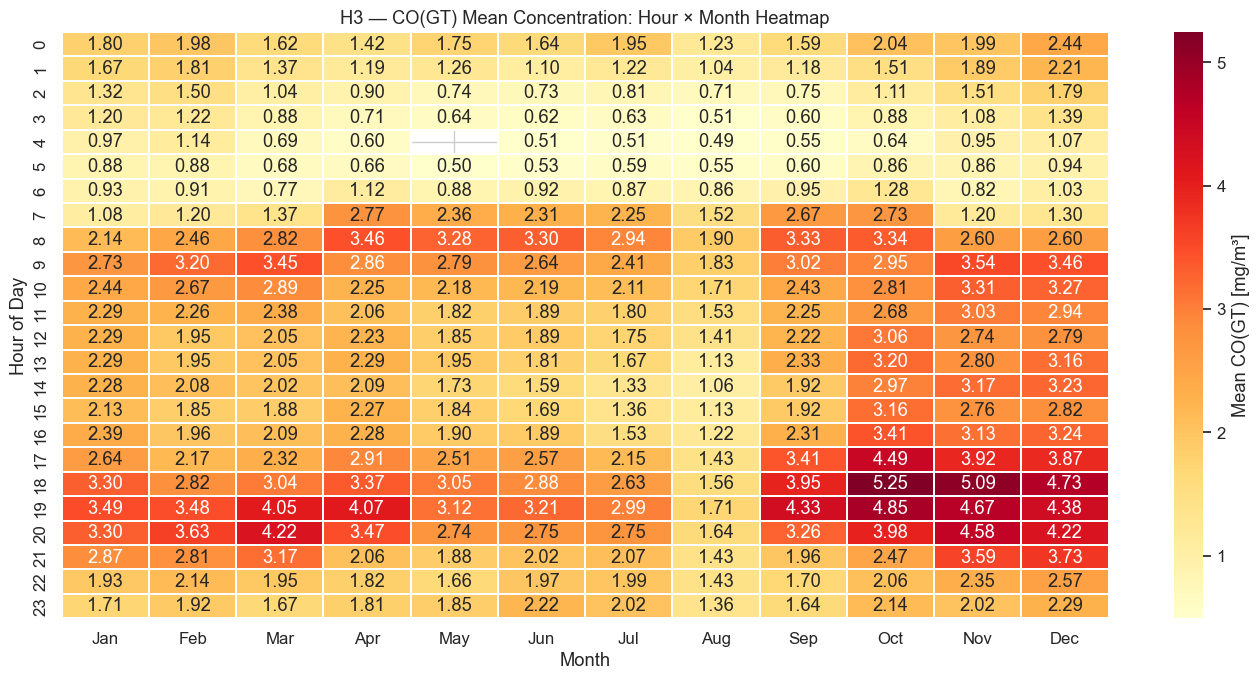

In [16]:
heatmap = h3['heatmap']
heatmap.columns = [month_names[m-1] for m in heatmap.columns]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(heatmap, cmap='YlOrRd', annot=True, fmt='.2f', linewidths=0.3,
            ax=ax, cbar_kws={'label': 'Mean CO(GT) [mg/m³]'})
ax.set_xlabel('Month')
ax.set_ylabel('Hour of Day')
ax.set_title('H3 — CO(GT) Mean Concentration: Hour × Month Heatmap')
plt.tight_layout()
plt.savefig('figures/h3_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 7 — H4: Inter-Pollutant Structure
**Hypothesis:** CO, NOx, C6H6 co-vary (r > 0.60); NO2 diverges as a secondary pollutant

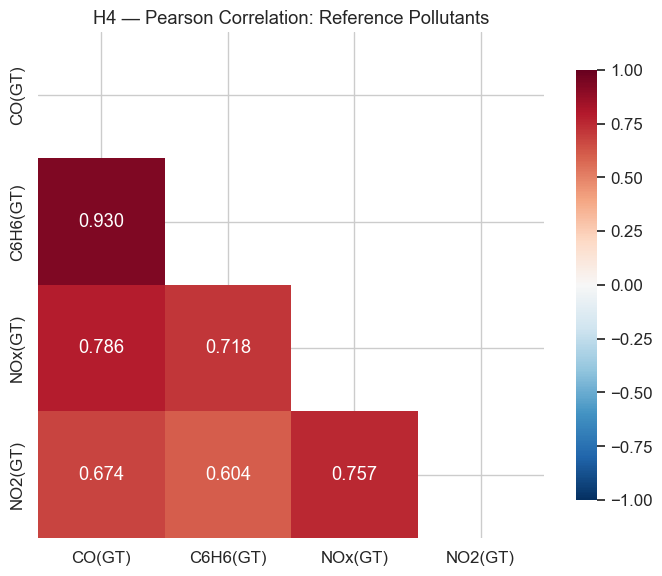

In [17]:
h4 = compute_h4_pca(df)

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(h4['corr'], dtype=bool))
sns.heatmap(h4['corr'], annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, mask=mask, ax=ax, square=True,
            cbar_kws={'shrink': 0.8})
ax.set_title('H4 — Pearson Correlation: Reference Pollutants')
plt.tight_layout()
plt.savefig('figures/h4_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
loadings = h4['loadings']
scores = h4['scores']

print('PCA Component Loadings:')
display(loadings.round(3))
print('\nExplained Variance:')
for i, ev in enumerate(h4['explained']):
    print(f'  PC{i+1}: {ev*100:.1f}%')

PCA Component Loadings:


,PC1,PC2,PC3,PC4
CO(GT),0.526,-0.370,-0.097,0.759
C6H6(GT),0.505,-0.537,-0.219,-0.639
NOx(GT),0.503,0.273,0.812,-0.111
NO2(GT),0.464,0.707,-0.532,-0.045



Explained Variance:
  PC1: 81.0%
  PC2: 12.0%
  PC3: 5.4%
  PC4: 1.6%


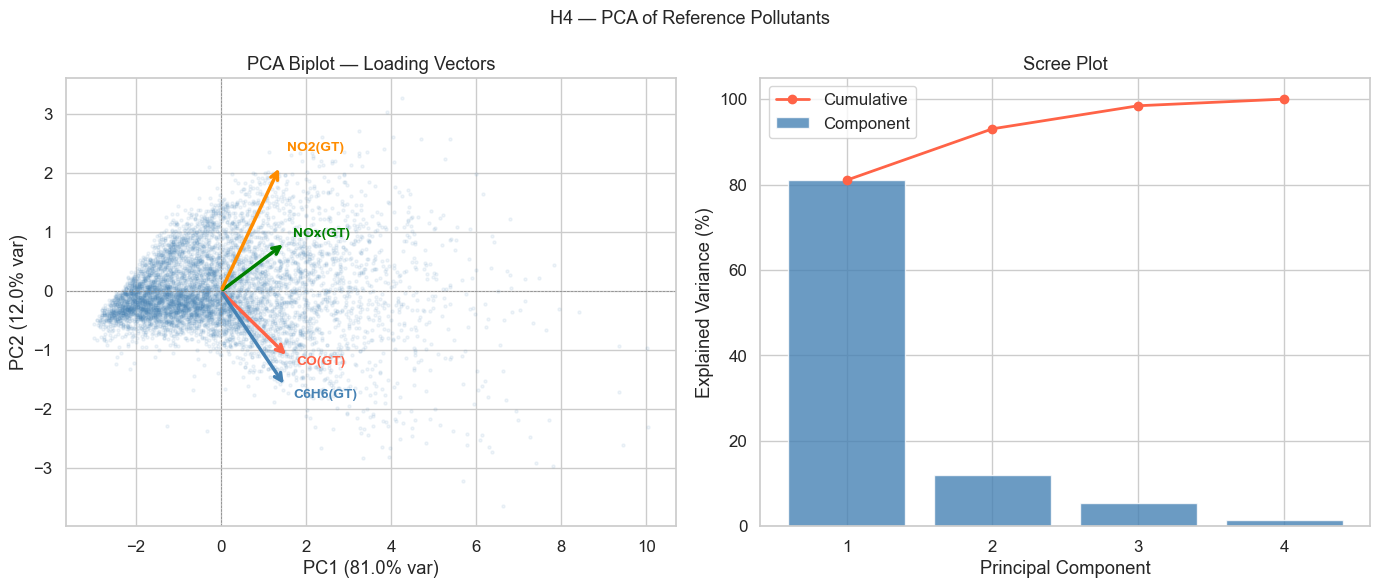

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Biplot
ax = axes[0]
ax.scatter(scores[:, 0], scores[:, 1], alpha=0.08, s=5, color='steelblue')
scale = 3.0
colors_pca = ['tomato', 'steelblue', 'green', 'darkorange']
for i, (col, c) in enumerate(zip(REF_COLS, colors_pca)):
    lx, ly = loadings.loc[col, 'PC1'] * scale, loadings.loc[col, 'PC2'] * scale
    ax.annotate('', xy=(lx, ly), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=c, lw=2.5))
    ax.text(lx*1.12, ly*1.12, col, fontsize=10, color=c, fontweight='bold')
ax.axhline(0, color='grey', lw=0.5, ls='--')
ax.axvline(0, color='grey', lw=0.5, ls='--')
ax.set_xlabel(f"PC1 ({h4['explained'][0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({h4['explained'][1]*100:.1f}% var)")
ax.set_title('PCA Biplot — Loading Vectors')

# Scree plot
ax2 = axes[1]
ev = h4['explained'] * 100
cumev = np.cumsum(ev)
ax2.bar(range(1, 5), ev, color='steelblue', alpha=0.8, label='Component')
ax2.plot(range(1, 5), cumev, 'o-', color='tomato', lw=2, label='Cumulative')
ax2.set_xticks(range(1, 5))
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Explained Variance (%)')
ax2.set_title('Scree Plot')
ax2.legend()

plt.suptitle('H4 — PCA of Reference Pollutants', fontsize=13)
plt.tight_layout()
plt.savefig('figures/h4_pca_biplot.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 8 — Results Summary

In [20]:
h1_res = compute_h1_correlations(df)
h3_res = compute_h3_temporal(df)
h4_res = compute_h4_pca(df)
h2_strat = compute_h2_stratified(df)

h2_sig = any(
    h2_ols[name].pvalues.get('T_x_sensor', 1) < 0.05 or
    h2_ols[name].pvalues.get('RH_x_sensor', 1) < 0.05
    for name in h2_ols
)

no2_pc1 = abs(h4_res['loadings'].loc['NO2(GT)', 'PC1'])
co_pc1  = abs(h4_res['loadings'].loc['CO(GT)',  'PC1'])
h4_supported = no2_pc1 < co_pc1

rows = [
    ('H1', 'C6H6 sensor', 'r > 0.80', f"r = {h1_res['C6H6']['r']:.3f}", abs(h1_res['C6H6']['r']) > 0.80),
    ('H1', 'CO sensor',   'r > 0.80', f"r = {h1_res['CO']['r']:.3f}",   abs(h1_res['CO']['r'])   > 0.80),
    ('H1', 'NOx sensor',  'r < 0.70', f"r = {h1_res['NOx']['r']:.3f}",  abs(h1_res['NOx']['r'])  < 0.70),
    ('H1', 'NO2 sensor',  'r < 0.70', f"r = {h1_res['NO2']['r']:.3f}",  abs(h1_res['NO2']['r'])  < 0.70),
    ('H2', 'T/RH interaction', 'Sig. interaction terms', 'See OLS output', h2_sig),
    ('H3', 'Diurnal ANOVA CO', 'p < 0.05',
     f"F={h3_res['anova_hour']['CO(GT)']['F']:.1f}, p={h3_res['anova_hour']['CO(GT)']['p']:.2e}",
     h3_res['anova_hour']['CO(GT)']['p'] < 0.05),
    ('H3', 'Seasonal ANOVA CO', 'p < 0.05',
     f"F={h3_res['anova_month']['CO(GT)']['F']:.1f}, p={h3_res['anova_month']['CO(GT)']['p']:.2e}",
     h3_res['anova_month']['CO(GT)']['p'] < 0.05),
    ('H4', 'NO2 diverges from traffic pollutants', 'Different PC loading',
     f"NO2 PC1 loading={h4_res['loadings'].loc['NO2(GT)','PC1']:.3f} vs CO={h4_res['loadings'].loc['CO(GT)','PC1']:.3f}",
     h4_supported),
]

summary = pd.DataFrame(rows, columns=['Hypothesis','Sub-test','Expected','Observed','Supported?'])
summary['Supported?'] = summary['Supported?'].map({True: '✅ Yes', False: '❌ No'})
display(summary.set_index(['Hypothesis','Sub-test']))

Expected  \
Hypothesis Sub-test                                                       
H1         C6H6 sensor                                         r > 0.80   
           CO sensor                                           r > 0.80   
           NOx sensor                                          r < 0.70   
           NO2 sensor                                          r < 0.70   
H2         T/RH interaction                      Sig. interaction terms   
H3         Diurnal ANOVA CO                                    p < 0.05   
           Seasonal ANOVA CO                                   p < 0.05   
H4         NO2 diverges from traffic pollutants    Different PC loading   

                                                                          Observed  \
Hypothesis Sub-test                                                                  
H1         C6H6 sensor                                                   r = 0.982   
           CO sensor                                                     r = 0.879   
           NOx sensor                                                   r = -0.656   
           NO2 sensor                                                    r = 0.158   
H2         T/RH interaction                                         See OLS output   
H3         Diurnal ANOVA CO                                    F=157.9, p=0.00e+00   
           Seasonal ANOVA CO                                   F=48.7, p=3.68e-104   
H4         NO2 diverges from traffic pollutants  NO2 PC1 loading=0.464 vs CO=0.526   

                                                Supported?  
Hypothesis Sub-test                                         
H1         C6H6 sensor                               ✅ Yes  
           CO sensor                                 ✅ Yes  
           NOx sensor                                ✅ Yes  
           NO2 sensor                                ✅ Yes  
H2         T/RH interaction                          ✅ Yes  
H3         Diurnal ANOVA CO                          ✅ Yes  
           Seasonal ANOVA CO                         ✅ Yes  
H4         NO2 diverges from traffic pollutants      ✅ Yes